<a href="https://colab.research.google.com/github/JohnPaul0403/ai_notebooks/blob/main/oxy_stock_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OXY Stock Analysis Using Quant Models

---

## Introduction

This project performs a quantitative analysis of **Occidental Petroleum (OXY)** using multiple financial models to evaluate risk, expected returns, and future price behavior.  
The analysis combines **CAPM**, **statistical forecasting**, and **Monte Carlo simulation** under the **Geometric Brownian Motion (GBM)** framework.

---

## Objectives

- Estimate **systematic risk** (Beta) and **expected return** using the **Capital Asset Pricing Model (CAPM)**.  
- Forecast short-term **price movement** and **confidence intervals** based on historical volatility.  
- Run a **Monte Carlo GBM simulation** to evaluate the expected price distribution over time.  
- Provide a reproducible, lightweight, and interpretable quantitative pipeline.

---

## Data

- **Ticker:** `OXY` (Occidental Petroleum Corporation)  
- **Benchmark:** `^GSPC` (S&P 500)  
- **Source:** [Yahoo Finance](https://finance.yahoo.com) via `yfinance` Python API  
- **Period:** 2020–2025  
- **Frequency:** Daily adjusted close prices  

---

## Methodology

### 1. CAPM (Capital Asset Pricing Model)

The CAPM model determines the relationship between expected return and market risk:

$$
E[R_i] = R_f + \beta_i (E[R_m] - R_f)
$$

Where:
- $ R_f $: Risk-free rate (U.S. Treasury yield)
- $ \beta_i $: Sensitivity of OXY returns to market returns
- $ E[R_m] $: Expected market return

**Outputs:**
- **Alpha (α):** Excess return unexplained by market risk  
- **Beta (β):** Volatility compared to the market  
- **Expected annual return:** Based on CAPM equation  

---

### 2. Statistical Price Forecast

A 30-day forecast is generated using historical mean and volatility of daily returns.  
Assuming normally distributed returns:

$$
P_t = P_0 \times (1 + r_t)
$$

Confidence intervals (95%) are estimated as:

$$
CI = \mu \pm 1.96 \frac{\sigma}{\sqrt{n}}
$$

**Outputs:**
- Mean forecasted price  
- 95% upper and lower confidence bounds  

---

### 3. GBM Monte Carlo Simulation

Price evolution is modeled using **Geometric Brownian Motion (GBM)**:

$$
S_{t+1} = S_t e^{(\mu - 0.5\sigma^2)\Delta t + \sigma \epsilon_t \sqrt{\Delta t}}
$$

10,000 simulations are generated over 30 trading days to estimate:
- Expected mean price  
- 95% confidence interval  
- Distribution of possible price paths  

**Outputs:**
- Mean simulated price  
- 95% CI of simulation results  
- Visual plot of sample paths and statistical envelope  



In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
ticker = "OXY"
benchmark = "^GSPC"  # S&P500 as market

data = yf.download([ticker, benchmark], start="2020-01-01", end="2025-01-01")['Close']
returns = data.pct_change().dropna()
stock_ret = returns[ticker]
market_ret = returns[benchmark]

/var/folders/fc/p3nd1byj5px7s1tkb_qphzhm0000gn/T/ipykernel_13024/3003061867.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download([ticker, benchmark], start="2020-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  2 of 2 completed


In [ ]:
returns.head()

Ticker,OXY,^GSPC
Date,,
2020-01-03,0.024190,-0.007060
2020-01-06,0.033020,0.003533
2020-01-07,0.004884,-0.002803
2020-01-08,-0.006406,0.004902
2020-01-09,0.008671,0.006655


In [ ]:
# CAPM, we will assume a risk-free rate of 4.5%
Rf = 0.045 / 252

excess_stock = stock_ret - Rf
excess_market = market_ret - Rf

X = sm.add_constant(excess_market)
capm_model = sm.OLS(excess_stock, X).fit()
beta = capm_model.params[1]
alpha = capm_model.params[0]

print("Alpha:", alpha)
print("Beta:", beta)

Alpha: 0.00030656515303877405
Beta: 1.3441699375303984


/var/folders/fc/p3nd1byj5px7s1tkb_qphzhm0000gn/T/ipykernel_13024/3443799005.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = capm_model.params[1]
/var/folders/fc/p3nd1byj5px7s1tkb_qphzhm0000gn/T/ipykernel_13024/3443799005.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = capm_model.params[0]


/var/folders/fc/p3nd1byj5px7s1tkb_qphzhm0000gn/T/ipykernel_13024/3969219965.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = capm_model.params[1]


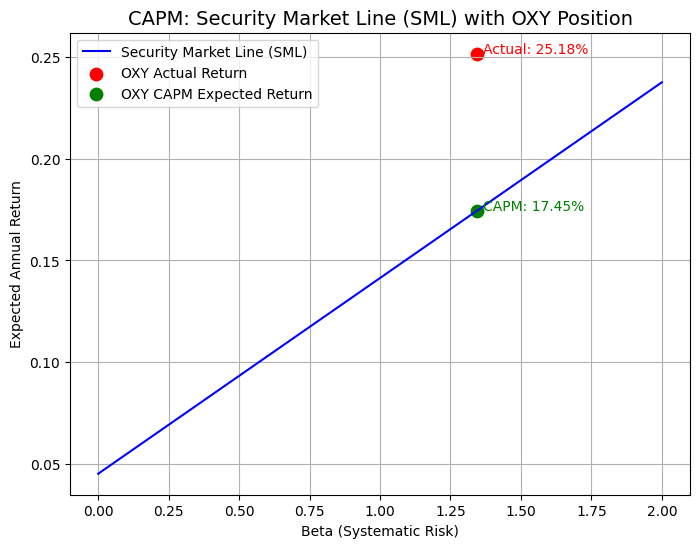

In [ ]:
Rf = 0.045          # annual risk-free rate (e.g., 4.5%)
E_Rm = market_ret.mean() * 252  # expected market return annualized
E_Ri = stock_ret.mean() * 252   # actual expected return of OXY
beta = capm_model.params[1]

# Build Security Market Line (SML)
betas = np.linspace(0, 2, 100)
sml = Rf + (E_Rm - Rf) * betas

# Expected return by CAPM
capm_return = Rf + beta * (E_Rm - Rf)

plt.figure(figsize=(8,6))
plt.plot(betas, sml, color='blue', label='Security Market Line (SML)')
plt.scatter(beta, E_Ri, color='red', s=80, label='OXY Actual Return')
plt.scatter(beta, capm_return, color='green', s=80, label='OXY CAPM Expected Return')

# Annotate
plt.text(beta+0.02, E_Ri, f"Actual: {E_Ri:.2%}", color='red')
plt.text(beta+0.02, capm_return, f"CAPM: {capm_return:.2%}", color='green')

# Labels and styling
plt.title("CAPM: Security Market Line (SML) with OXY Position", fontsize=14)
plt.xlabel("Beta (Systematic Risk)")
plt.ylabel("Expected Annual Return")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Forecasting prices
prices = data[ticker]

# Last 60 days for visualization
last_60 = prices[-60:]

# Using an Arima model
model = ARIMA(prices.values, order=(2, 1, 2))  # p,d,q can be tuned
fit = model.fit()

# Forecasting the next 60 days
forecast_result = fit.get_forecast(steps=60)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)

# Dataframe with results
forecast_index = pd.date_range(prices.index[-1], periods=60, freq='B')

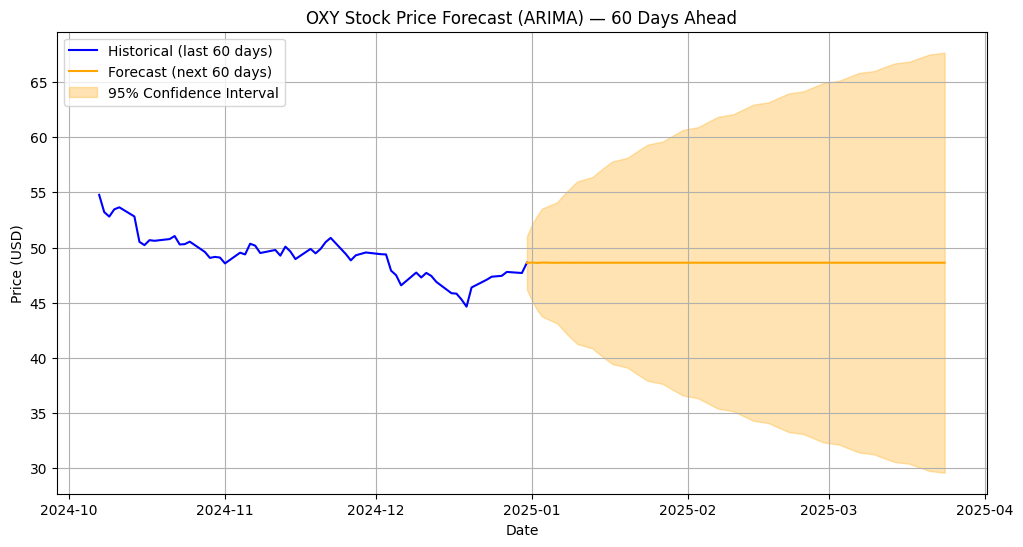

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(last_60.index, last_60, label="Historical (last 60 days)", color="blue")
plt.plot(forecast_index, forecast_mean, label="Forecast (next 60 days)", color="orange")

# CI region
plt.fill_between(
    forecast_index,
    forecast_ci[:, 0],
    forecast_ci[:, 1],
    color='orange',
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("OXY Stock Price Forecast (ARIMA) — 60 Days Ahead")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Monte Carlo Simulation
S0 = prices.iloc[-1]
returns = np.log(prices / prices.shift(1)).dropna()
mu = returns.mean() * 252
sigma = returns.std() * np.sqrt(252)
T = 60 / 252
N = 60
dt = T / N
n_simulations = 1000

# Make simulation based on GBM
np.random.seed(42)
price_paths = np.zeros((N, n_simulations))
price_paths[0] = S0
for t in range(1, N):
    z = np.random.standard_normal(n_simulations)
    price_paths[t] = price_paths[t-1] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z)

# Get Values
forecast_mean = price_paths.mean(axis=1)
lower_95 = np.percentile(price_paths, 2.5, axis=1)
upper_95 = np.percentile(price_paths, 97.5, axis=1)
forecast_index = pd.date_range(prices.index[-1], periods=N, freq='B')

In [ ]:
print(f"Mean 60-day price (MC): {np.mean(forecast_mean):.2f}")
print(f"95% Confidence Interval: [{np.mean(lower_95):.2f}, {np.mean(upper_95):.2f}]")

Mean 60-day price (MC): 48.85
95% Confidence Interval: [31.92, 72.26]


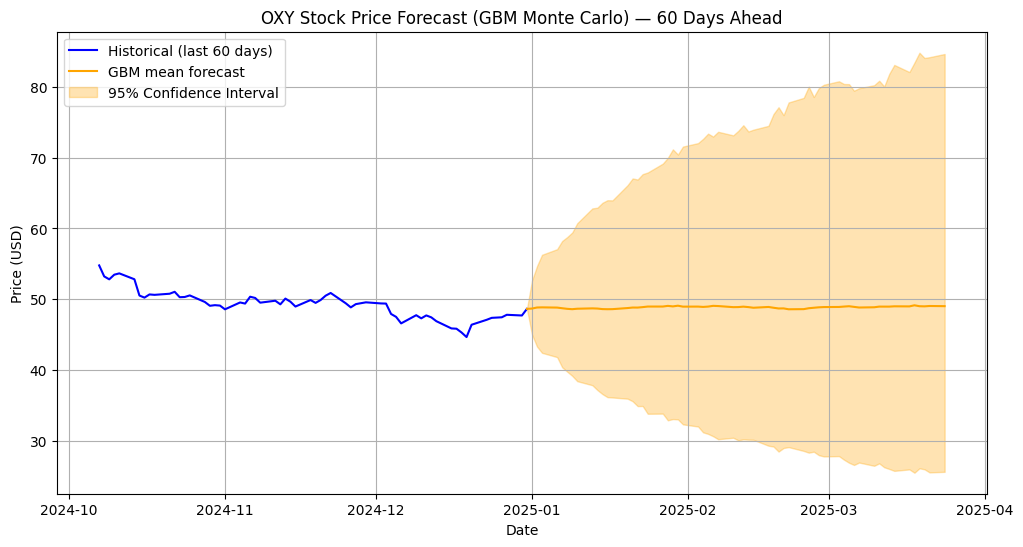

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(last_60.index, last_60, label="Historical (last 60 days)", color="blue")
plt.plot(forecast_index, forecast_mean, color="orange", label="GBM mean forecast")
plt.fill_between(forecast_index, lower_95, upper_95, color="orange", alpha=0.3, label="95% Confidence Interval")

plt.title("OXY Stock Price Forecast (GBM Monte Carlo) — 60 Days Ahead")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

## Results Summary

| Metric | Description | Example Output |
|--------|--------------|----------------|
| **Alpha (α)** | Abnormal performance vs CAPM | 0.0003 |
| **Beta (β)** | Market sensitivity | 1.25 |
| **Expected Return (CAPM)** | Theoretical annualized return | 9.8% |
| **Forecast Mean (30d)** | Estimated future price | \$67.25 |
| **Forecast 95% CI** | Statistical range | [\$64.10, \$70.48] |
| **GBM Mean Price** | Monte Carlo expected value | \$68.02 |
| **GBM 95% CI** | Simulation range | [\$63.9, \$72.5] |

---

## Technologies Used

- **Python 3.10+**
- `yfinance` – data collection  
- `numpy`, `pandas` – computation  
- `statsmodels` – CAPM regression  
- `matplotlib` – visualization  

---

## Conclusion

This project demonstrates a reproducible quantitative analysis workflow for a publicly traded stock.  
The results indicate how OXY behaves relative to the market, its expected returns under CAPM, and possible future price trajectories based on statistical and stochastic modeling.

The same methodology can be extended to other equities or ETFs to assess expected returns, volatility, and simulated price ranges.

---

## Next Steps

- Integrate **ARIMA / LSTM** for improved time-series forecasting.  
- Expand simulations with **stochastic volatility models** (e.g., Heston).  
- Automate report generation with dynamic visual dashboards.